# 01. Exploratory analysis and data cleansing

Before I trust a forecast I have to trust the data under it. This notebook
earns that trust the hard way. It checks every timestamp and join, justifies
each cleansing step, finds the non-linear structure the models will have to
capture, and writes out the committed panel and the season-blocked split
labels every later notebook reads. `scripts/build_dataset.py` mirrors these
steps headlessly.

**The data.** NSW1 demand from AEMO's aggregated price-and-demand archive
(`TOTALDEMAND`, five-minute dispatch averaged to half hours), three years of
it from May 2023. It is paired with ERA5 reanalysis weather and archived
ECMWF IFS day-ahead forecasts from Open-Meteo, both hourly and interpolated
onto the half-hourly grid. The long history is deliberate: it lets the
evaluation split cover every season in both validation and test. Everything
is stored and modelled in UTC with period-start timestamps, and plotted in
AEST, the NEM market clock. Weather data by
[Open-Meteo](https://open-meteo.com/) (CC BY 4.0). Combining data sources is
fraught with danger, but no other non-commercial sources were available.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from nemforecastdemand.config import load_config
from nemforecastdemand.data import weather
from nemforecastdemand.data.loaders import MARKET_TZ, load_splits
from nemforecastdemand.features.calendar import holiday_flag
from nemforecastdemand.features.preprocessing import build_panel, half_hourly_grid
from nemforecastdemand.plotting import (
    DISPLAY_TZ,
    LOCAL_TZ,
    display_index,
    format_date_axis,
    palette,
    plot_clock_profile,
    save_figure,
    setup_style,
)
from nemforecastdemand.splits import season_blocked_split, split_labels, split_summary

setup_style()
cfg = load_config()

In [2]:
demand = (
    pl.read_parquet(cfg.paths.interim / "demand.parquet").to_pandas().set_index("ts")["demand_mw"]
)
era5 = weather.load_raw(cfg.paths.raw / "weather" / "era5.parquet")
forecast = weather.load_raw(cfg.paths.raw / "weather" / "forecast.parquet")
demand.describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
demand_mw,53184.0,7488.80721,1471.243115,2581.838333,6530.478333,7364.160833,8326.99875,13715.565


*Takeaway: three years of half-hourly demand, centred near 8 GW, with no obvious scale problems to clean up.*

## Timestamp and timezone audit

Three time conventions coincide in this dataset, and each is a classic source
of silent misalignment: the kind of bug that shifts a forecast by hours and
never throws an error. So I verify them rather than assume them.

1. AEMO stamps half hours with their **ending** time in market time (AEST, a
   fixed UTC+10 with no daylight saving). The data layer shifts these to
   period-start stamps and converts to UTC.
2. Open-Meteo series were requested in UTC directly.
3. NSW behaviour follows the **local Sydney clock**, which moves against both
   UTC and market time at the daylight-saving transitions.

First the grid itself: the demand series should cover every half hour of the
window exactly once.

In [3]:
grid = half_hourly_grid(demand.index[0], demand.index[-1])
audit = pd.DataFrame(
    {
        "expected half hours": [len(grid)],
        "present": [len(demand)],
        "missing": [len(grid.difference(demand.index))],
        "duplicates": [int(demand.index.duplicated().sum())],
        "first (AEST)": [display_index(demand.index[:1])[0]],
        "last (AEST)": [display_index(demand.index[-1:])[0]],
    }
)
audit

,expected half hours,present,missing,duplicates,first (AEST),last (AEST)
0,53184,53184,0,0,2023-05-18 00:00:00+10:00,2026-05-29 23:30:00+10:00


*Takeaway: the grid is complete and duplicate-free, running market midnight to market midnight as intended.*

### The daily shape moves with the local clock, not the market clock

Market time has no daylight saving, but Sydney does. If I profile demand
against the market clock, the whole daily shape should jump by an hour the
moment daylight saving begins. The four weeks either side of the October 2025
transition show it cleanly, and re-profiling against the local clock should
make the jump disappear. This is not cosmetic: seasonal features built on the
market clock would smear the morning and evening ramps for half the year, so
every calendar feature here is computed from the local clock.

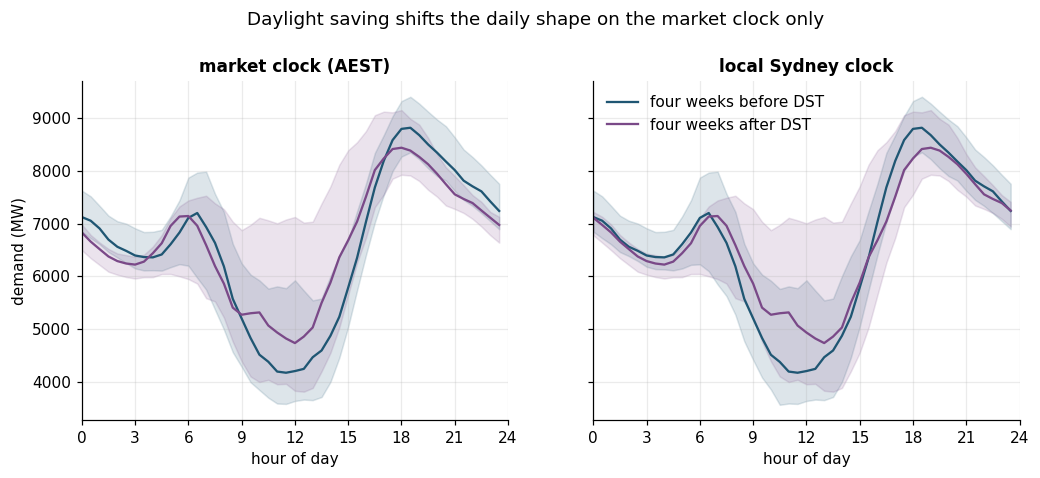

In [4]:
before_dst = demand.loc["2025-09-07":"2025-10-04"]
after_dst = demand.loc["2025-10-06":"2025-11-02"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tz, title in (
    (axes[0], DISPLAY_TZ, "market clock (AEST)"),
    (axes[1], LOCAL_TZ, "local Sydney clock"),
):
    plot_clock_profile(ax, before_dst, tz, "four weeks before DST", palette("demand"))
    plot_clock_profile(ax, after_dst, tz, "four weeks after DST", palette("accent"))
    ax.set_title(title)
axes[0].set_ylabel("demand (MW)")
axes[1].legend()
fig.suptitle("Daylight saving shifts the daily shape on the market clock only", y=1.04)
save_figure(fig, "dst_daily_shape", cfg.paths.figures)
plt.show()

*Takeaway: the hour-wide displacement on the left collapses on the right, confirming both the timezone handling and the choice of clock for seasonal features.*

### Cross-checking the demand-weather join

A timezone slip in either series would shift the demand-weather relationship
by hours and quietly poison every weather coefficient. I check the join two
ways.

**Temperature.** Correlating the raw series would mostly measure the phase gap
between two daily cycles, so I use anomalies instead: each summer series minus
its own mean daily profile. A hot spell lifts demand within a few hours, with
demand trailing temperature, so the correlation should peak a little above
zero lag and nowhere near the ten hours a UTC-versus-AEST slip would give.

**Irradiance.** Sunlight obeys astronomy. Direct normal irradiance has to be
zero through the local night and peak near local solar noon, an exact,
demand-free check of the weather clock.

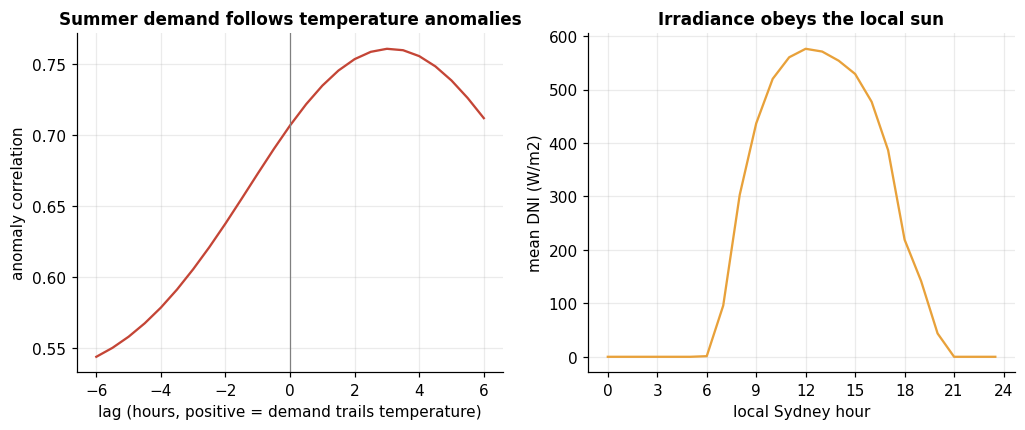

temperature anomaly correlation peaks at +3.0 h; DNI profile peaks at 12.0 local, night-time max 0.0 W/m2


In [5]:
summer = slice("2025-12-01", "2026-02-28")
temp_half_hourly = (
    era5["temperature_2m"].reindex(era5.index.union(grid)).interpolate("time").reindex(grid)
)
dni_half_hourly = (
    era5["direct_normal_irradiance"]
    .reindex(era5.index.union(grid))
    .interpolate("time")
    .reindex(grid)
)


def daily_anomaly(series: pd.Series) -> pd.Series:
    local_clock = series.index.tz_convert(LOCAL_TZ)
    step = local_clock.hour * 2 + local_clock.minute // 30
    return series - series.groupby(step).transform("mean")


demand_anomaly = daily_anomaly(demand.loc[summer])
temp_anomaly = daily_anomaly(temp_half_hourly.loc[summer])
lags = np.arange(-12, 13)
ccf = pd.Series([demand_anomaly.corr(temp_anomaly.shift(int(k))) for k in lags], index=lags / 2.0)

local_hour = dni_half_hourly.index.tz_convert(LOCAL_TZ).hour + (
    dni_half_hourly.index.tz_convert(LOCAL_TZ).minute / 60
)
dni_profile = dni_half_hourly.groupby(local_hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ccf.index, ccf, color=palette("temperature"))
axes[0].axvline(0, color="grey", lw=0.8)
axes[0].set_xlabel("lag (hours, positive = demand trails temperature)")
axes[0].set_ylabel("anomaly correlation")
axes[0].set_title("Summer demand follows temperature anomalies")
axes[1].plot(dni_profile.index, dni_profile, color=palette("irradiance"))
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("mean DNI (W/m2)")
axes[1].set_xticks(np.arange(0, 25, 3))
axes[1].set_title("Irradiance obeys the local sun")
plt.show()

night = dni_half_hourly[
    np.isin(dni_half_hourly.index.tz_convert(LOCAL_TZ).hour, [22, 23, 0, 1, 2, 3])
]
print(
    f"temperature anomaly correlation peaks at {ccf.idxmax():+.1f} h; "
    f"DNI profile peaks at {dni_profile.idxmax():.1f} local, night-time max {night.max():.1f} W/m2"
)

*Takeaway: the temperature lag peaks at a few hours (thermal inertia, not a timezone slip), and irradiance is zero at night and peaks at local noon, which pins the weather clock exactly.*

One thing I deliberately leave out is the demand-irradiance anomaly
correlation: sunshine cuts demand immediately through rooftop PV but raises it
a few hours later through heat, and the two channels cancel near zero lag.
That same confounding is why temperature and both irradiance components all go
into the feature set together.

## What drives NSW1 demand?

The window spans three years, so every season recurs and the year-on-year
trend is there to see. Demand carries a strong daily cycle, a weekly cycle, a
U-shaped temperature response (heating below roughly 17 C, cooling above
roughly 20 C) and the midday suppression rooftop solar now imposes.

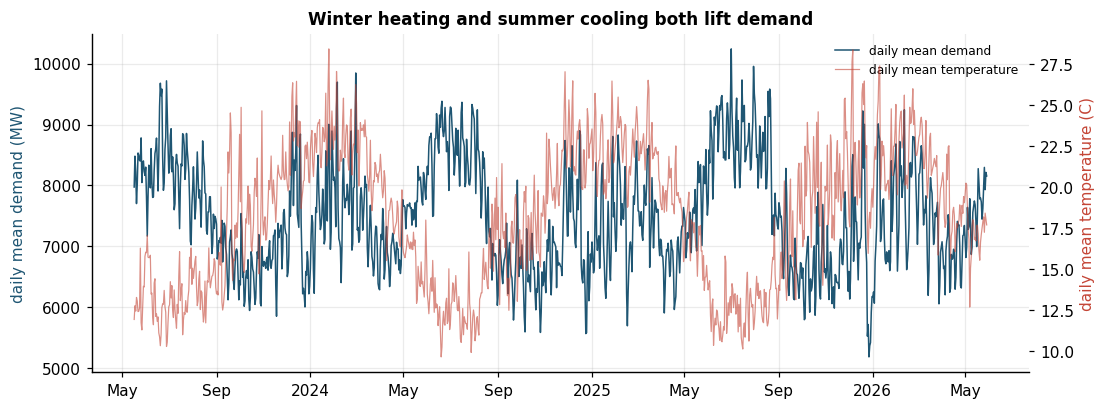

In [6]:
daily_mean = demand.resample("1D").mean()
daily_temp = temp_half_hourly.resample("1D").mean()

fig, ax = plt.subplots()
(line_demand,) = ax.plot(
    display_index(daily_mean.index),
    daily_mean,
    color=palette("demand"),
    lw=1.0,
    label="daily mean demand",
)
ax.set_ylabel("daily mean demand (MW)", color=palette("demand"))
twin = ax.twinx()
(line_temp,) = twin.plot(
    display_index(daily_temp.index),
    daily_temp,
    color=palette("temperature"),
    lw=0.8,
    alpha=0.6,
    label="daily mean temperature",
)
twin.set_ylabel("daily mean temperature (C)", color=palette("temperature"))
twin.grid(False)
format_date_axis(ax)
ax.set_title("Winter heating and summer cooling both lift demand")
ax.legend(handles=[line_demand, line_temp], loc="upper right", fontsize=8)
plt.show()

*Takeaway: demand rises at both temperature extremes, so the response is U-shaped, not monotone.*

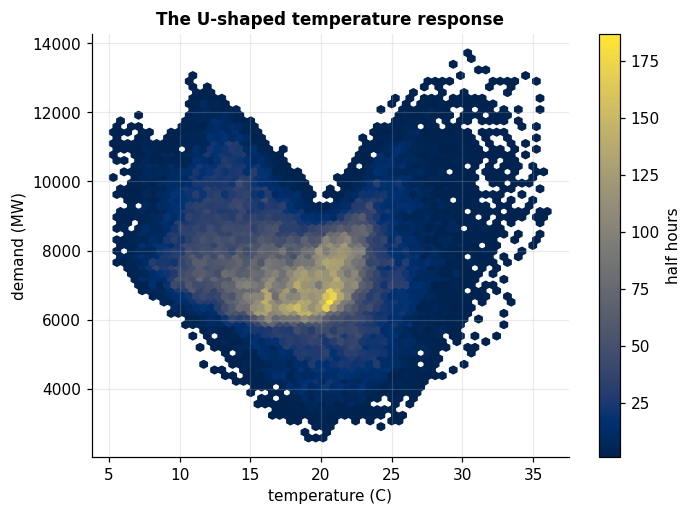

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(temp_half_hourly, demand, gridsize=60, cmap="cividis", mincnt=1)
ax.set_xlabel("temperature (C)")
ax.set_ylabel("demand (MW)")
ax.set_title("The U-shaped temperature response")
fig.colorbar(hb, label="half hours")
save_figure(fig, "demand_temperature", cfg.paths.figures)
plt.show()

*Takeaway: the trough sits around 17 to 20 C, which sets the heating and cooling bases for the degree-day features; the vertical spread is the daily cycle.*

Dew point joins dry-bulb temperature in the feature set because humid summer
evenings keep air conditioning running at temperatures that would otherwise
need none. Rooftop solar is the other thing that defines the modern load
shape: splitting days by midday irradiance shows sunny days hollowed out in
the middle, which is why direct and diffuse irradiance enter the design too.

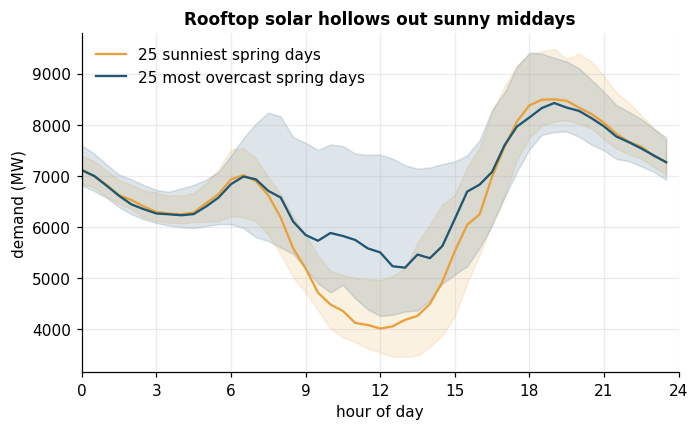

In [8]:
local = demand.index.tz_convert(LOCAL_TZ)
midday = (local.hour >= 10) & (local.hour < 14)
midday_dni = dni_half_hourly[midday].groupby(local[midday].date).mean()
spring = midday_dni.loc[
    (pd.to_datetime(midday_dni.index) >= "2025-09-01")
    & (pd.to_datetime(midday_dni.index) < "2025-12-01")
]
sunny = demand[np.isin(local.date, spring.nlargest(25).index)]
overcast = demand[np.isin(local.date, spring.nsmallest(25).index)]

fig, ax = plt.subplots(figsize=(7, 4))
plot_clock_profile(ax, sunny, LOCAL_TZ, "25 sunniest spring days", palette("irradiance"))
plot_clock_profile(ax, overcast, LOCAL_TZ, "25 most overcast spring days", palette("demand"))
ax.set_ylabel("demand (MW)")
ax.set_title("Rooftop solar hollows out sunny middays")
ax.legend()
save_figure(fig, "duck_curve", cfg.paths.figures)
plt.show()

*Takeaway: sunny middays sit well below overcast ones, the rooftop-PV signal that direct and diffuse irradiance are in the design to capture.*

The weekly cycle and the public-holiday effect round out the calendar
structure. Weekends and holidays drop the working-hours load, and holidays
behave like Sundays whatever the weekday, which is what motivates the holiday
indicator in the design.

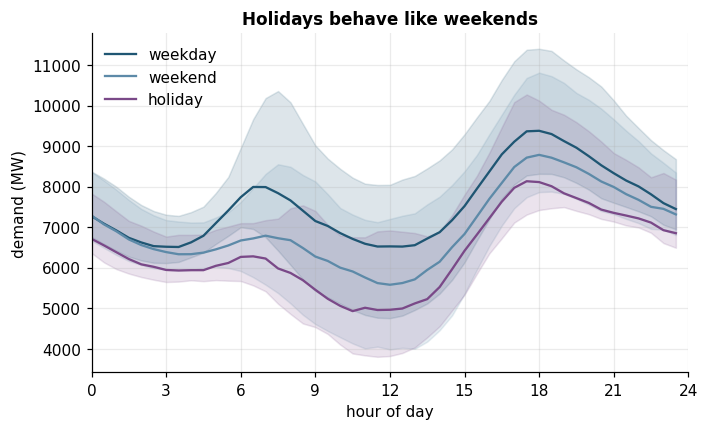

In [9]:
local_dow = demand.index.tz_convert(LOCAL_TZ).dayofweek
day_type = pd.Series(
    np.select(
        [holiday_flag(demand.index).to_numpy(), local_dow >= 5],
        ["holiday", "weekend"],
        default="weekday",
    ),
    index=demand.index,
)

fig, ax = plt.subplots(figsize=(7, 4))
for kind, colour in (
    ("weekday", palette("demand")),
    ("weekend", palette("forecast")),
    ("holiday", palette("accent")),
):
    plot_clock_profile(ax, demand[day_type == kind], DISPLAY_TZ, kind, colour)
ax.set_ylabel("demand (MW)")
ax.set_title("Holidays behave like weekends")
ax.legend()
plt.show()

*Takeaway: holidays track the weekend profile, not the weekday one, which justifies a single holiday flag.*

## How good are the day-ahead weather forecasts?

The headline evaluation feeds the models the ECMWF IFS forecast exactly as it
was issued one day earlier, so the forecast's own error against ERA5 is part
of the story. Two caveats belong out in the open. First, the coefficients are
trained on ERA5 actuals while the forecasts come from a different model with
its own climatology, a mild train/serve mismatch; bias-correcting the
forecast onto ERA5 is noted as future work. Second, ERA5 is itself reanalysis,
not station truth. The residual structure below does double duty: it also
calibrates the perturbation sweep used in notebook 05.

In [10]:
panel, report = build_panel(
    pl.read_parquet(cfg.paths.interim / "demand.parquet"), era5, forecast, cfg
)
residuals = pd.DataFrame(
    {
        "temperature (C)": panel["temp_fc_c"] - panel["temp_c"],
        "dew point (C)": panel["dew_fc_c"] - panel["dew_c"],
        "DNI (W/m2)": panel["dni_fc_wm2"] - panel["dni_wm2"],
    }
)
residuals.describe().loc[["mean", "std", "min", "max"]].T

,mean,std,min,max
temperature (C),-0.346435,0.929041,-7.199999,5.700001
dew point (C),-0.135893,1.119761,-10.200001,6.900000
DNI (W/m2),-17.712221,88.769531,-640.400024,739.800049


*Takeaway: day-ahead forecast biases are small; the spread is what the perturbation sweep will reuse.*

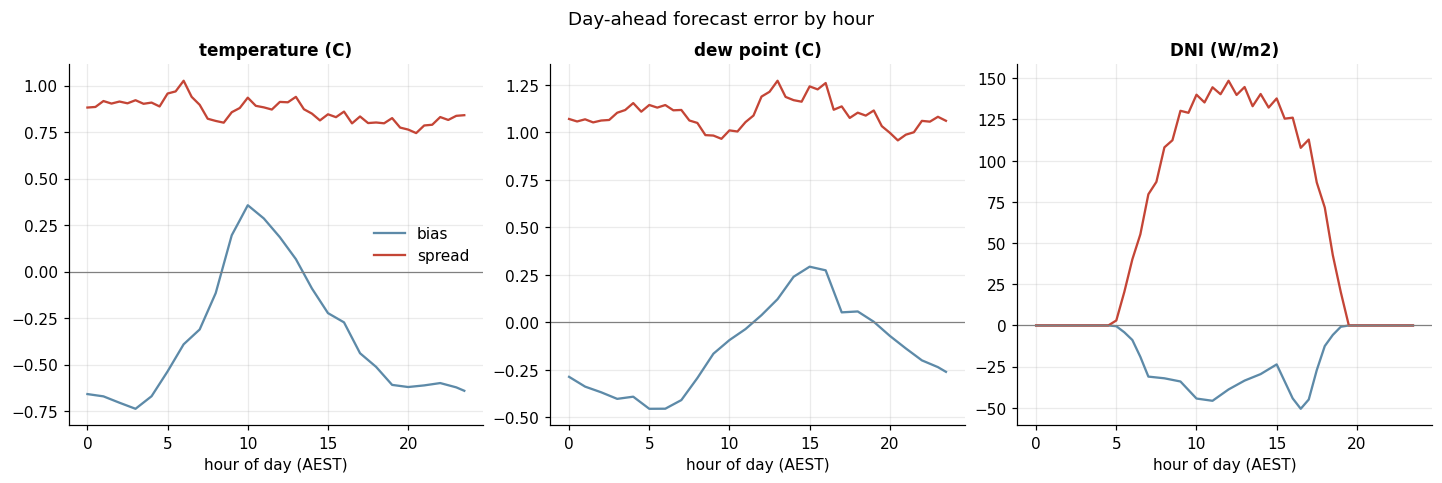

In [11]:
hour = panel.index.tz_convert(DISPLAY_TZ).hour + panel.index.tz_convert(DISPLAY_TZ).minute / 60
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, column in zip(axes, residuals.columns, strict=True):
    grouped = residuals[column].groupby(hour)
    ax.plot(grouped.mean().index, grouped.mean(), color=palette("forecast"), label="bias")
    ax.plot(grouped.std().index, grouped.std(), color=palette("temperature"), label="spread")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_title(column)
    ax.set_xlabel("hour of day (AEST)")
axes[0].legend()
fig.suptitle("Day-ahead forecast error by hour", y=1.06)
plt.show()

*Takeaway: errors run around half a degree at night and a degree in the afternoon, and irradiance error concentrates in daylight where cloud timing is hard. Small enough to leave a weather signal, large enough that perfect-foresight scoring would flatter every model, which is why notebook 05 scores both variants.*

## Cleansing

The panel build applies three guarded repairs, each counted and surfaced
rather than done silently: interpolation of demand gaps up to one hour, a
Hampel screen (a rolling weekly median, eight scaled MADs) for telemetry
spikes, and interpolation of short weather-forecast gaps with an actuals
fallback. The thresholds are deliberately conservative, because a genuine
demand peak is signal, not a fault.

A Hampel screen is a robust outlier filter. It slides a window along the
series, takes the median as the local centre, and measures spread with the
median absolute deviation (MAD), the median of the absolute gaps between the
observations and that centre. The MAD is multiplied by 1.4826 so it reads as a
standard deviation would under a normal, and a point is flagged when it sits
more than `k` of those scaled MADs from the local median. Here the window is a
centred week and `k` is eight, deliberately loose: the median and the MAD are
unmoved by the very spike being screened, where a mean and a standard deviation
would be dragged out by it, so the filter catches telemetry faults without
touching a genuine evening peak.

In [12]:
report.as_frame().sort_values("column").reset_index(drop=True)

,column,repair,count
0,apptemp_fc_c,interpolated,6954
1,apptemp_fc_c,filled from actuals,13832
2,demand_mw,missing on grid,0
3,demand_mw,interpolated,0
4,demand_mw,outliers replaced,0
5,dew_fc_c,interpolated,6954
6,dew_fc_c,filled from actuals,13832
7,dhi_fc_wm2,interpolated,7097
8,dhi_fc_wm2,filled from actuals,14118
9,dni_fc_wm2,interpolated,7097


*Takeaway: nothing needed repair in this window; the zero counts are themselves evidence the upstream feeds are well curated, and the screens stay in for future reruns.*

## Season-blocked splits

A single year of demand cannot support an honest seasonal evaluation. A plain
chronological cut drops one season into validation and a different one into
test, so anything tuned on validation is judged out of season. Three years of
history allow better. I keep everything before June 2025 as one contiguous
training block, then carve the final year into monthly pairs of five-day
windows and send one window of each month to validation and the other to test.
Both evaluation sets then span all twelve months.

Two properties keep this leakage-clean:

- The training block ends before every evaluation window, so no fitting target
  sits behind an evaluation point and no lagged feature of a training row can
  reach one.
- The validation/test slot is drawn by a balanced seed, half early-window and
  half late-window for each set, so neither is skewed within the month.

In [13]:
splits = season_blocked_split(panel.index, cfg.splits)
labels = split_labels(panel.index, splits)
cfg.paths.processed.mkdir(parents=True, exist_ok=True)
panel.to_parquet(cfg.paths.processed / "panel.parquet")
pd.DataFrame({"split": labels}).to_parquet(cfg.paths.processed / "split_labels.parquet")
load_splits(cfg.paths.processed)
split_summary(splits)

,first,last,half_hours,days
split,,,,
train,2023-05-18 00:00:00+10:00,2025-05-31 23:30:00+10:00,35760,745.0
validation,2025-06-08 00:00:00+10:00,2026-05-23 23:30:00+10:00,2880,60.0
test,2025-06-19 00:00:00+10:00,2026-05-12 23:30:00+10:00,2880,60.0


*Takeaway: training is one solid multi-year block, and validation and test each carry every month.*

split     test validation
month                    
2025-06   late      early
2025-07   late      early
2025-08  early       late
2025-09   late      early
2025-10   late      early
2025-11  early       late
2025-12  early       late
2026-01   late      early
2026-02  early       late
2026-03  early       late
2026-04   late      early
2026-05  early       late


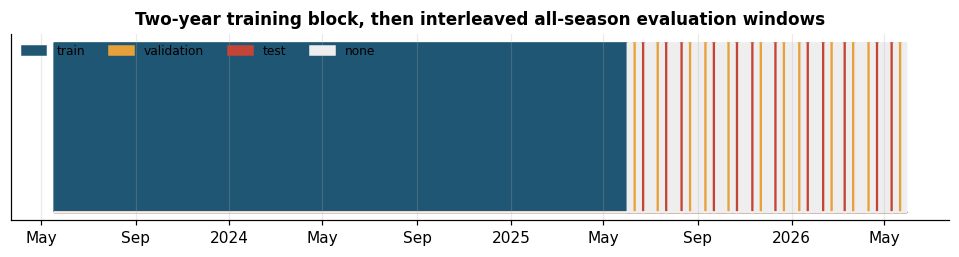

In [14]:
month_market = panel.index.tz_convert(LOCAL_TZ)
assignment = pd.DataFrame(
    {
        "month": pd.PeriodIndex(labels.index.tz_convert(MARKET_TZ), freq="M").astype(str),
        "split": labels.to_numpy(),
        "day": labels.index.tz_convert(MARKET_TZ).day,
    }
)
eval_assignment = assignment[assignment["split"].isin(["validation", "test"])]
slot = eval_assignment.assign(
    window=lambda d: np.where(d["day"] <= 12, "early", "late")
).pivot_table(index="month", columns="split", values="window", aggfunc="first")
print(slot.to_string())

fig, ax = plt.subplots(figsize=(11, 2.2))
colours = {"train": "#1f5673", "validation": "#e8a13a", "test": "#c44536", "none": "#eeeeee"}
for name, colour in colours.items():
    mask = labels.to_numpy() == name
    if mask.any():
        ax.fill_between(
            display_index(labels.index), 0, mask.astype(float), step="mid", color=colour, label=name
        )
ax.set_yticks([])
ax.set_title("Two-year training block, then interleaved all-season evaluation windows")
ax.legend(loc="upper left", ncol=4, fontsize=8)
format_date_axis(ax)
save_figure(fig, "split_map", cfg.paths.figures)
plt.show()

*Takeaway: the leakage guarantee reads off the map: validation and test windows only begin once the training block has ended.*

## Trigonometric or radial seasonal basis?

The daily and weekly cycles can be written as Fourier harmonics or as periodic
Gaussian radial basis functions over the same local-clock phases, with the
column counts matched so model size stays fixed. A plain least-squares
regression of demand on the full design settles which basis carries the
seasonal shape better as a predictor: fit on train, score on validation, no
leakage. Notebook 02 refits this comparison inside the full ARIMA.

In [15]:
from dataclasses import replace

from nemforecastdemand.models.base import build_design

y_all = panel["demand_mw"].astype(np.float64)
basis_rows = {}
basis_errors = {}
for basis in ("fourier", "rbf"):
    basis_cfg = replace(cfg, features=replace(cfg.features, seasonal_basis=basis))
    design = build_design(panel, basis_cfg, weather_source="actual")
    train_design = design.loc[splits["train"]].dropna()
    val_design = design.loc[splits["validation"]]
    train_matrix = np.column_stack([np.ones(len(train_design)), train_design.to_numpy()])
    val_matrix = np.column_stack([np.ones(len(val_design)), val_design.to_numpy()])
    coef, *_ = np.linalg.lstsq(train_matrix, y_all.loc[train_design.index].to_numpy(), rcond=None)
    errors = y_all.loc[val_design.index] - val_matrix @ coef
    basis_errors[basis] = errors
    basis_rows[basis] = {
        "design columns": design.shape[1],
        "validation MAE (MW)": float(errors.abs().mean()),
        "validation RMSE (MW)": float(np.sqrt((errors**2).mean())),
    }
pd.DataFrame(basis_rows).T

,design columns,validation MAE (MW),validation RMSE (MW)
fourier,58.0,379.318120,528.258156
rbf,56.0,379.192844,528.480423


*Takeaway: the two bases land within noise of each other at matched size.*

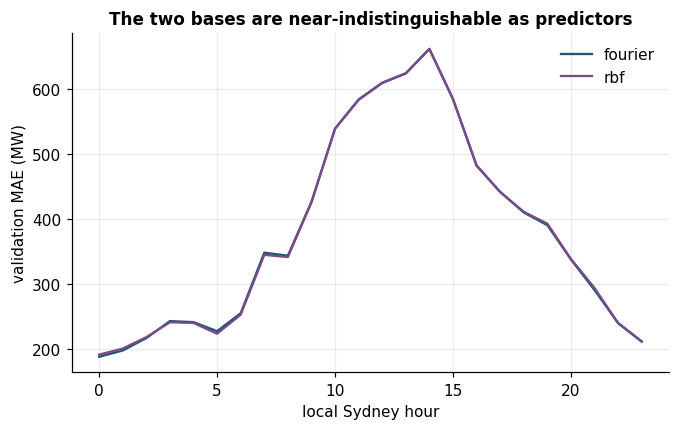

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
for basis, colour in (("fourier", palette("demand")), ("rbf", palette("accent"))):
    hourly_mae = (
        basis_errors[basis]
        .abs()
        .groupby(basis_errors[basis].index.tz_convert(LOCAL_TZ).hour)
        .mean()
    )
    ax.plot(hourly_mae.index, hourly_mae, label=basis, color=colour)
ax.set_xlabel("local Sydney hour")
ax.set_ylabel("validation MAE (MW)")
ax.set_title("The two bases are near-indistinguishable as predictors")
ax.legend()
plt.show()

*Takeaway: even through the sharp morning ramp the two bases barely differ. I keep the trigonometric basis as default for its exact periodicity; the RBF basis is one config switch away.*

## Which weather variables earn their place

Temperature, dew point and the two irradiance components are already in.
Several other weather fields might carry demand signal. I screen each
candidate the model-free way: by how strongly its own anomaly correlates with
the demand anomaly, where an anomaly is the series minus its mean profile by
half-hour-of-week. Working in anomalies strips out the daily and weekly cycles
that would otherwise dominate any raw correlation. No model is fitted here.
The transform matters as much as the field, so apparent temperature enters as
degree days and wind as a heating interaction, the way a model would use them.

In [17]:
candidates = pd.read_parquet(cfg.paths.raw / "weather" / "era5_candidates.parquet")
if candidates.index.tz is None:
    candidates.index = candidates.index.tz_localize("UTC")
cand_grid = (
    candidates.reindex(candidates.index.union(panel.index)).interpolate("time").reindex(panel.index)
)

local_week = panel.index.tz_convert(LOCAL_TZ)
profile_key = pd.Series(
    local_week.dayofweek * 48 + local_week.hour * 2 + local_week.minute // 30, index=panel.index
)


def week_anomaly(series: pd.Series) -> pd.Series:
    """Series minus its empirical mean by half-hour-of-week (no model fitted)."""
    s = series.astype(float)
    return s - s.groupby(profile_key).transform("mean")


hb, cb = cfg.weather.heating_base, cfg.weather.cooling_base
heat_deg = np.maximum(hb - panel["temp_c"], 0.0)
candidate_series = {
    "apparent heating degrees": np.maximum(hb - cand_grid["apparent_temperature"], 0.0),
    "wind x heating": cand_grid["wind_speed_10m"] * heat_deg,
    "shortwave radiation (GHI)": cand_grid["shortwave_radiation"],
    "apparent cooling degrees": np.maximum(cand_grid["apparent_temperature"] - cb, 0.0),
    "relative humidity": cand_grid["relative_humidity_2m"],
    "cloud cover": cand_grid["cloud_cover"],
    "apparent temperature (raw)": cand_grid["apparent_temperature"],
    "wind gusts": cand_grid["wind_gusts_10m"],
    "precipitation": cand_grid["precipitation"],
    "surface pressure": cand_grid["surface_pressure"],
    "wind speed (raw)": cand_grid["wind_speed_10m"],
}
demand_train_anom = week_anomaly(y_all).loc[splits["train"]].to_numpy()
screen = pd.Series(
    {
        name: abs(
            np.corrcoef(demand_train_anom, week_anomaly(series).loc[splits["train"]].to_numpy())[
                0, 1
            ]
        )
        for name, series in candidate_series.items()
    }
).sort_values()
screen.round(3).to_frame("|anomaly correlation|")

,|anomaly correlation|
wind speed (raw),0.030
surface pressure,0.032
precipitation,0.056
cloud cover,0.083
wind gusts,0.102
apparent temperature (raw),0.195
apparent cooling degrees,0.209
relative humidity,0.210
shortwave radiation (GHI),0.374
wind x heating,0.428


*Takeaway: the three transformed fields I keep (apparent heating degrees, wind x heating, GHI) lead the field; the raw and redundant fields sit well below.*

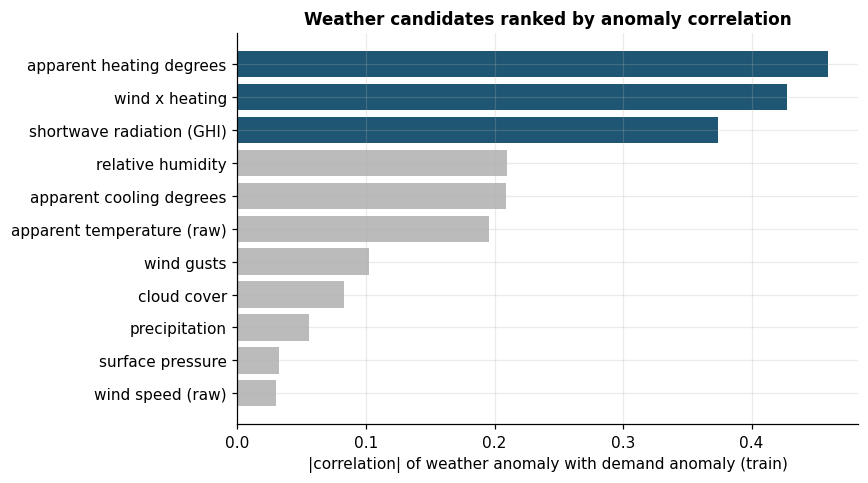

In [18]:
chosen = {"apparent heating degrees", "wind x heating", "shortwave radiation (GHI)"}
fig, ax = plt.subplots(figsize=(8, 4.5))
colours = [palette("demand") if n in chosen else "#bbbbbb" for n in screen.index]
ax.barh(screen.index, screen.to_numpy(), color=colours)
ax.set_xlabel("|correlation| of weather anomaly with demand anomaly (train)")
ax.set_title("Weather candidates ranked by anomaly correlation")
fig.tight_layout()
save_figure(fig, "weather_variable_selection", cfg.paths.figures)
plt.show()

*Takeaway: three candidates earn their place, all transformed.*

Apparent-temperature degree days fold humidity and wind into a feels-like
temperature; global horizontal irradiance adds the behind-the-meter rooftop-PV
signal that direct and diffuse miss; and wind interacted with heating degrees
captures heat loss on cold days. Those three are promoted into the modelled
design. Relative humidity sits mid-table but adds little once apparent
temperature, which already folds it in, is present. Raw wind, gusts,
precipitation and pressure sit near zero. The raw fields underperform their
transforms, which is why the design carries the transforms.

## What stays non-linear after the linear design

A design that enters every model linearly deserves a check for the
interactions it cannot represent. Fitting the additive design on train and
tabulating the residual mean by time-of-day block and temperature band gives a
direct signature: a purely additive temperature response would leave these
cells near zero.

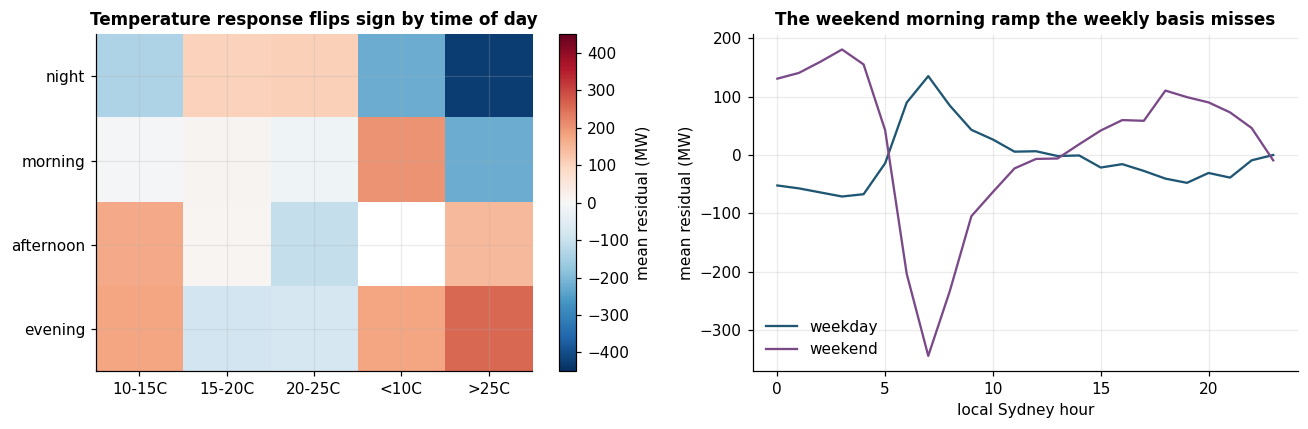

In [19]:
plain_cfg = replace(cfg, features=replace(cfg.features, interaction_harmonics=0))
design = build_design(panel, plain_cfg, weather_source="actual")
train_design = design.loc[splits["train"]].dropna()
train_matrix = np.column_stack([np.ones(len(train_design)), train_design.to_numpy()])
coef, *_ = np.linalg.lstsq(train_matrix, y_all.loc[train_design.index].to_numpy(), rcond=None)
resid = pd.Series(
    y_all.loc[train_design.index].to_numpy() - train_matrix @ coef, index=train_design.index
)

local_resid = resid.index.tz_convert(LOCAL_TZ)
signature = pd.DataFrame(
    {
        "resid": resid.to_numpy(),
        "block": pd.cut(
            local_resid.hour,
            [0, 6, 12, 18, 24],
            labels=["night", "morning", "afternoon", "evening"],
            right=False,
        ),
        "temp": pd.cut(
            train_design["temp_c"],
            [-5, 10, 15, 20, 25, 45],
            labels=["<10C", "10-15C", "15-20C", "20-25C", ">25C"],
        ).to_numpy(),
        "weekend": local_resid.dayofweek >= 5,
        "hour": local_resid.hour,
    }
)
pivot = signature.pivot_table(
    values="resid", index="block", columns="temp", aggfunc="mean", observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(pivot.to_numpy(), cmap="RdBu_r", vmin=-450, vmax=450, aspect="auto")
axes[0].set_xticks(range(pivot.shape[1]), pivot.columns)
axes[0].set_yticks(range(pivot.shape[0]), pivot.index)
fig.colorbar(im, ax=axes[0], label="mean residual (MW)")
axes[0].set_title("Temperature response flips sign by time of day")

weekend_gap = signature.pivot_table(values="resid", index="hour", columns="weekend", aggfunc="mean")
axes[1].plot(weekend_gap.index, weekend_gap[False], color=palette("demand"), label="weekday")
axes[1].plot(weekend_gap.index, weekend_gap[True], color=palette("accent"), label="weekend")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("mean residual (MW)")
axes[1].set_title("The weekend morning ramp the weekly basis misses")
axes[1].legend()
fig.tight_layout()
save_figure(fig, "nonlinearity_signature", cfg.paths.figures)
plt.show()

*Takeaway: two interaction signatures remain: hot evenings sit hundreds of MW above the additive fit while hot nights sit below it, and weekend mornings run far from the weekday profile.*

Both stay linear in parameters once the right columns exist: degree days and a
weekend flag, each interacted with a small daily Fourier basis. The size of
that basis is selected on validation and fitted on train only.

In [20]:
interaction_rows = {}
for n_ix in (0, 2, 3):
    ix_cfg = replace(cfg, features=replace(cfg.features, interaction_harmonics=n_ix))
    design = build_design(panel, ix_cfg, weather_source="actual")
    train_design = design.loc[splits["train"]].dropna()
    val_design = design.loc[splits["validation"]]
    train_matrix = np.column_stack([np.ones(len(train_design)), train_design.to_numpy()])
    val_matrix = np.column_stack([np.ones(len(val_design)), val_design.to_numpy()])
    coef, *_ = np.linalg.lstsq(train_matrix, y_all.loc[train_design.index].to_numpy(), rcond=None)
    errors = y_all.loc[val_design.index] - val_matrix @ coef
    interaction_rows[f"{n_ix} interaction harmonics"] = {
        "design columns": design.shape[1],
        "validation MAE (MW)": float(errors.abs().mean()),
        "validation RMSE (MW)": float(np.sqrt((errors**2).mean())),
    }
pd.DataFrame(interaction_rows).T

,design columns,validation MAE (MW),validation RMSE (MW)
0 interaction harmonics,45.0,414.524782,567.417341
2 interaction harmonics,58.0,379.318120,528.258156
3 interaction harmonics,64.0,380.175264,529.471254


*Takeaway: two harmonics capture the gain and more buys nothing, so the interaction block is switched on at two and every model downstream sees the same enriched design.*

## The spread varies too, so the observation scale is heteroskedastic

The cells above tabulate the residual mean. The residual spread is every bit
as structured: demand is far noisier in the evening peak and on hot days than
in the small hours or in mild weather. A single constant predictive scale
would over-cover the calm hours and under-cover the volatile ones. This is the
evidence for a heteroskedastic observation scale, here a log-linear function
of a small daily basis and degree days. I take it from the data rather than
pricing it in with a later ablation.

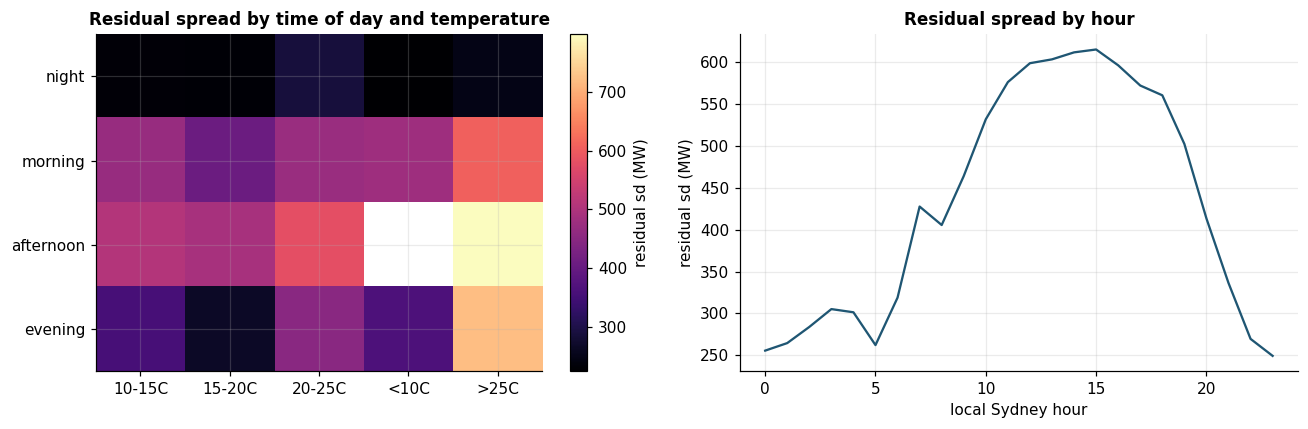

residual sd ranges 249 to 615 MW by hour (2.5-fold), and climbs with temperature: a constant scale cannot match that, so the observation scale is log-linear and heteroskedastic


In [21]:
std_pivot = signature.pivot_table(
    values="resid", index="block", columns="temp", aggfunc="std", observed=True
)
std_by_hour = signature.groupby("hour")["resid"].std()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(std_pivot.to_numpy(), cmap="magma", aspect="auto")
axes[0].set_xticks(range(std_pivot.shape[1]), std_pivot.columns)
axes[0].set_yticks(range(std_pivot.shape[0]), std_pivot.index)
fig.colorbar(im, ax=axes[0], label="residual sd (MW)")
axes[0].set_title("Residual spread by time of day and temperature")
axes[1].plot(std_by_hour.index, std_by_hour.to_numpy(), color=palette("demand"))
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("residual sd (MW)")
axes[1].set_title("Residual spread by hour")
fig.tight_layout()
save_figure(fig, "heteroskedasticity", cfg.paths.figures)
plt.show()
print(
    f"residual sd ranges {std_by_hour.min():.0f} to {std_by_hour.max():.0f} MW by hour "
    f"({std_by_hour.max() / std_by_hour.min():.1f}-fold), and climbs with temperature: a constant "
    "scale cannot match that, so the observation scale is log-linear and heteroskedastic"
)

*Takeaway: the residual spread varies several-fold across the day and climbs with temperature, so the observation scale has to be heteroskedastic.*

## Summary

What the data has shown, before a single model is fitted:

- The half-hourly grid is complete, duplicate-free and verified against both
  the interval-ending-to-period-start and the AEST-to-UTC conversions.
- Daily structure follows the local Sydney clock through daylight saving, so
  every seasonal feature is built on local-clock phases.
- Lagged correlations place the demand-weather join within a couple of hours
  of zero, ruling out a timezone slip.
- Demand shows daily, weekly and holiday structure, a U-shaped temperature
  response around a 17 to 20 C comfort band, and solar suppression of the
  midday load.
- The additive design leaves two interaction signatures in its train
  residuals, closed by degree-day and weekend interactions with two daily
  harmonics, selected on validation.
- Three extra weather transforms earn their place by anomaly correlation:
  apparent degree days, GHI and wind x heating.
- The observation scale has to be heteroskedastic.
- The train, validation and test splits are written, validated and committed.